<a href="https://colab.research.google.com/github/DianaShpytchuk/Sales_Analytics/blob/main/Python_for_DA_Module_Task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")

# Changing work folder
%cd /content/drive/MyDrive/Mate_Academy/Python/Final_Project

# Uploading dataset
events = pd.read_csv("events.csv")
products = pd.read_csv("products.csv")
countries = pd.read_csv("countries.csv")
events.head()

Mounted at /content/drive
/content/drive/MyDrive/Mate_Academy/Python/Final_Project


,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [ ]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1330 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1330 non-null   int64  
 1   Order Date      1330 non-null   object 
 2   Ship Date       1330 non-null   object 
 3   Order Priority  1330 non-null   object 
 4   Country Code    1248 non-null   object 
 5   Product ID      1330 non-null   int64  
 6   Sales Channel   1330 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1330 non-null   float64
 9   Unit Cost       1330 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 104.0+ KB


In [ ]:
events.describe()

,Order ID,Product ID,Units Sold,Unit Price,Unit Cost
count,1.330000e+03,1330.000000,1328.000000,1330.000000,1330.000000
mean,5.412048e+08,5788.096241,4952.201807,264.893541,187.246812
std,2.573882e+08,2820.728878,2905.198996,217.323460,176.158873
min,1.006406e+08,1270.000000,2.000000,9.330000,6.920000
25%,3.190004e+08,3127.000000,2356.750000,81.730000,35.840000
50%,5.387164e+08,5988.000000,4962.000000,154.060000,97.440000
75%,7.544628e+08,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,8969.000000,9999.000000,668.270000,524.960000


### **Data cleaning**

In [ ]:
#Кількість пропущених значень
print(events.isna().sum())

Order ID          0
Order Date        0
Ship Date         0
Order Priority    0
Country Code      0
Product ID        0
Sales Channel     0
Units Sold        0
Unit Price        0
Unit Cost         0
dtype: int64


In [ ]:
#Доля пропущених значень у загальній кількості
print(events.isna().sum() / events.shape[0] * 100)

Order ID          0.0
Order Date        0.0
Ship Date         0.0
Order Priority    0.0
Country Code      0.0
Product ID        0.0
Sales Channel     0.0
Units Sold        0.0
Unit Price        0.0
Unit Cost         0.0
dtype: float64


In [ ]:
# Перевірка дублікатів - відсутні
duplicate_rows = events.duplicated()
print(duplicate_rows)
print(duplicate_rows.sum())

0       False
1       False
2       False
3       False
4       False
        ...  
1325    False
1326    False
1327    False
1328    False
1329    False
Length: 1330, dtype: bool
0


In [ ]:
#Заміна відсутніх значень
events["Country Code"] = events["Country Code"].fillna("Unknown")
events["Units Sold"] = events["Units Sold"].fillna(events["Units Sold"].median())

#Перетворення типів стовбців
events['Order Date'] = pd.to_datetime(events['Order Date'])
events['Ship Date'] = pd.to_datetime(events['Ship Date'])
events['Units Sold'] = events['Units Sold'].astype(int)

### **Data analysis and visualization**

In [ ]:
#Об'єднання таблиць
df = events.merge(products, left_on='Product ID', right_on='id')
df = df.merge(countries, left_on='Country Code', right_on='alpha-3')
df = df.drop(columns=['alpha-3', 'id', 'alpha-2'])
#Робота з назвами стовбців
df.columns = df.columns.str.lower().str.replace('-', '_').str.replace(' ', '_')
#Створення нових колонок
df['total_revenue'] = df['units_sold'] * df['unit_price']
df['total_cost'] = df['units_sold'] * df['unit_cost']
df['profit'] = df['total_revenue'] - df['total_cost']
#Розставлення рядків у зручному порядку
df = df[['order_id',
        'order_date',
        'ship_date',
        'order_priority',
        'product_id',
        'item_type',
        'sales_channel',
        'units_sold',
        'unit_price',
        'total_revenue',
        'unit_cost',
        'total_cost',
        'profit',
        'name',
        'region',
        'sub_region',
        'country_code'
       ]]

df.head()

,order_id,order_date,ship_date,order_priority,product_id,item_type,sales_channel,units_sold,unit_price,total_revenue,unit_cost,total_cost,profit,name,region,sub_region,country_code
0,100640618,2014-10-08,2014-10-18,M,2103,Cereal,Online,650,205.70,133705.00,117.11,76121.50,57583.50,Norway,Europe,Northern Europe,NOR
1,100983083,2016-08-11,2016-08-11,C,2103,Cereal,Offline,1993,205.70,409960.10,117.11,233400.23,176559.87,Serbia,Europe,Southern Europe,SRB
2,102230632,2017-05-13,2017-06-13,L,2455,Clothes,Online,1171,109.28,127966.88,35.84,41968.64,85998.24,Montenegro,Europe,Southern Europe,MNE
3,103435266,2012-08-11,2012-09-18,H,1270,Beverages,Offline,7648,47.45,362897.60,31.79,243129.92,119767.68,Serbia,Europe,Southern Europe,SRB
4,103450715,2015-03-15,2015-04-18,H,8681,Office Supplies,Online,2220,651.21,1445686.20,524.96,1165411.20,280275.00,Slovakia,Europe,Eastern Europe,SVK


**order_id** — унікальний ідентифікатор замовлення  
**order_date** — дата оформлення замовлення  
**ship_date** — дата отримання замовлення    
**order_priority** — пріоритет обробки замовлення     
**product_id** — унікальний ідентифікатор товару     
**item_type** — тип або категорія товару      
**sales_channel** — канал продажу (онлайн або офлайн)    
**units_sold** — кількість проданих одиниць товару    
**unit_price** — ціна однієї одиниці товару     
**total_revenue** - загальна вартість однієї покупки  
**unit_cost** — собівартість однієї одиниці товару  
**total_cost** - загальна собівартість однієї покупки  
**profit** - прибуток
**name** — назва країни    
**region** — великий географічний регіон світу     
**sub_region** — підрегіон всередині великого регіону    
**country_code** — код країни за міжнародним стандартом
      

### **Key metrics**

In [ ]:
date_range = df['order_date'].agg(['min', 'max'])
print(f"Дата першого оформлення замовлення: {date_range['min']}")
print(f"Дата останнього оформлення замовлення: {date_range['max']}")

Дата першого оформлення замовлення: 2010-01-01 00:00:00
Дата останнього оформлення замовлення: 2017-07-22 00:00:00


In [ ]:
total_number_of_orders = df['order_id'].nunique()
print(f"Загальна кількість замовлень: {total_number_of_orders}")

Загальна кількість замовлень: 1248


In [ ]:
total_number_of_units_sold = df['units_sold'].sum()
print(f"Загальна кількість проданих одиниць товару: {total_number_of_units_sold}")


Загальна кількість проданих одиниць товару: 6181595


In [ ]:
total_number_of_country = df['name'].nunique()
print(f"Загальна кількість залучених країн: {total_number_of_country}")

Загальна кількість залучених країн: 45


In [ ]:
average_delivery_time = (df['ship_date'] - df['order_date']).mean()
print(f"Середня кількість днів для доставки: {average_delivery_time}")


Середня кількість днів для доставки: 1248


Загальна вартість всіх продаж: 1601482723.7$
Загальна собівартість всіх продаж: 1127365514.52$
Прибуток: 474117209.17999995$


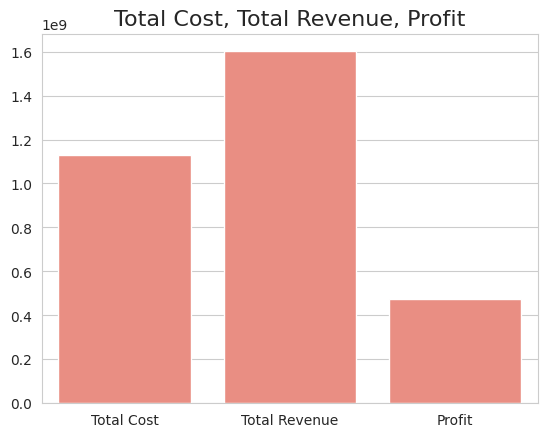

In [ ]:
revenue = df['total_revenue'].sum()
print(f"Загальна вартість всіх продаж: {revenue}$")
cost = df['total_cost'].sum()
print(f"Загальна собівартість всіх продаж: {cost}$")
profit = df['profit'].sum()
print(f"Прибуток: {profit}$")

sns.set_style("whitegrid")
sns.barplot(x=['Total Cost', 'Total Revenue', 'Profit'],
            y=[cost, revenue, profit],
            color="Salmon")
plt.title('Total Cost, Total Revenue, Profit', fontsize=16)
plt.show()




### **Sales analysis**

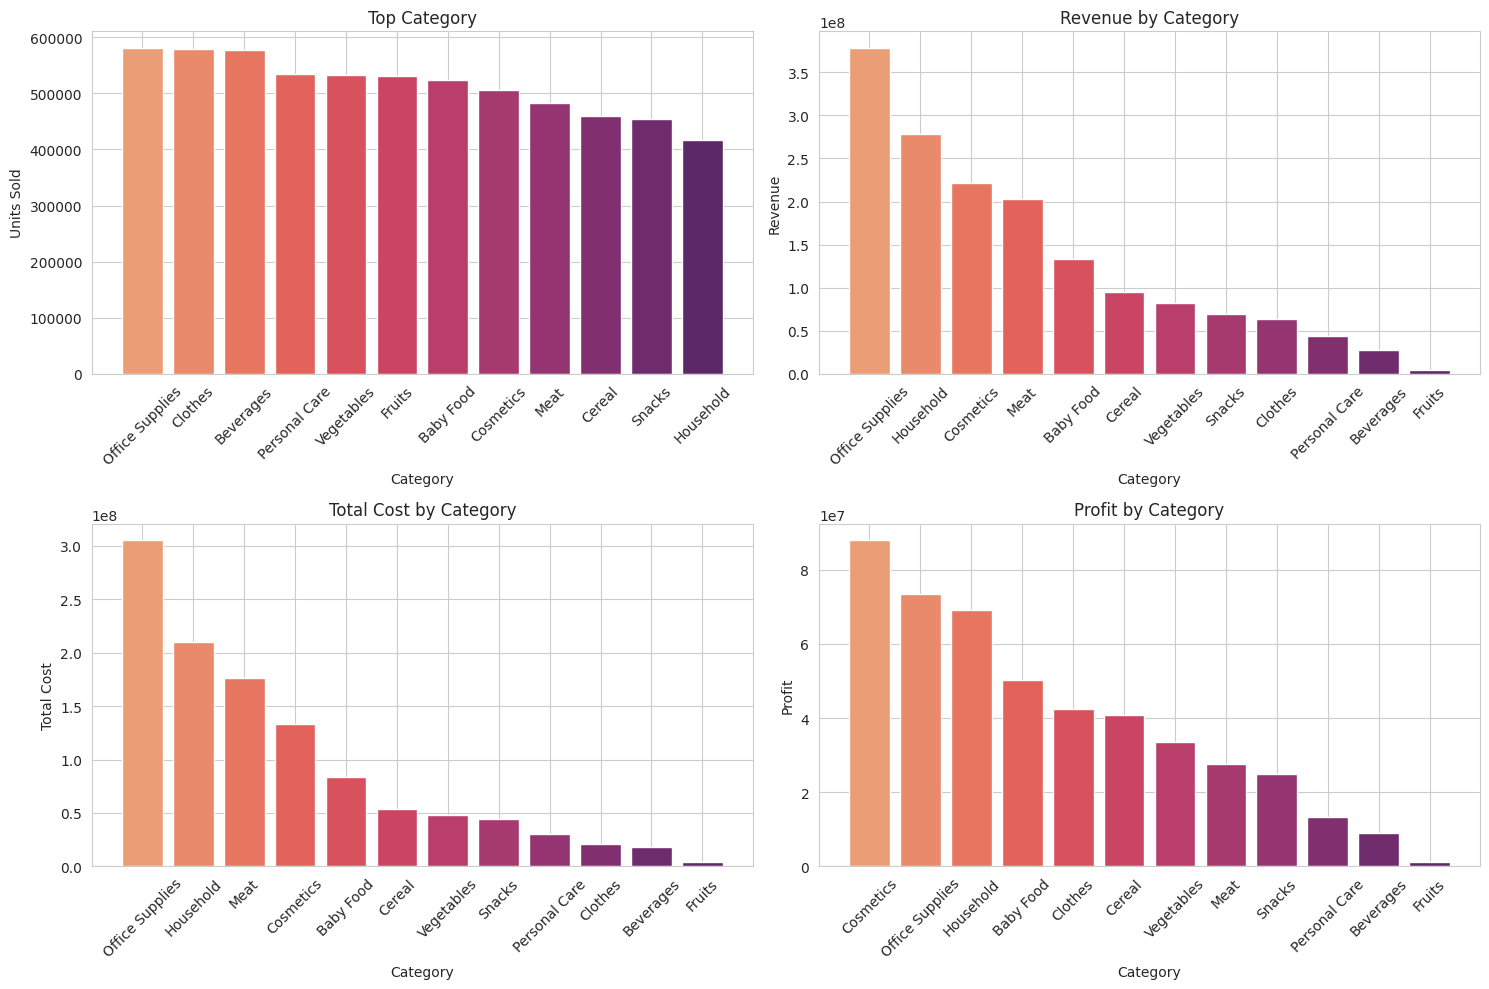

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10))

top_category = df.groupby('item_type')['units_sold'].sum().sort_values(ascending=False)
revenue_by_category = df.groupby('item_type')['total_revenue'].sum().sort_values(ascending=False)
total_cost_by_category = df.groupby('item_type')['total_cost'].sum().sort_values(ascending=False)
profit_by_category = df.groupby('item_type')['profit'].sum().sort_values(ascending=False)
colors = sns.color_palette("flare", len(top_category))


ax[0, 0].bar(top_category.index, top_category.values, color=colors)
ax[0, 0].set_title('Top Category')
ax[0, 0].set_xlabel('Category')
ax[0, 0].tick_params(axis='x', rotation=45)
ax[0, 0].set_ylabel('Units Sold')

ax[0, 1].bar(revenue_by_category.index, revenue_by_category.values, color=colors)
ax[0, 1].set_title('Revenue by Category')
ax[0, 1].set_xlabel('Category')
ax[0, 1].tick_params(axis='x', rotation=45)
ax[0, 1].set_ylabel('Revenue')

ax[1, 0].bar(total_cost_by_category.index, total_cost_by_category.values, color=colors)
ax[1, 0].set_title('Total Cost by Category')
ax[1, 0].set_xlabel('Category')
ax[1, 0].tick_params(axis='x', rotation=45)
ax[1, 0].set_ylabel('Total Cost')

ax[1, 1].bar(profit_by_category.index, profit_by_category.values, color=colors)
ax[1, 1].set_title('Profit by Category')
ax[1, 1].set_xlabel('Category')
ax[1, 1].tick_params(axis='x', rotation=45)
ax[1, 1].set_ylabel('Profit')

plt.tight_layout()
plt.show()


### **Analysis by country**

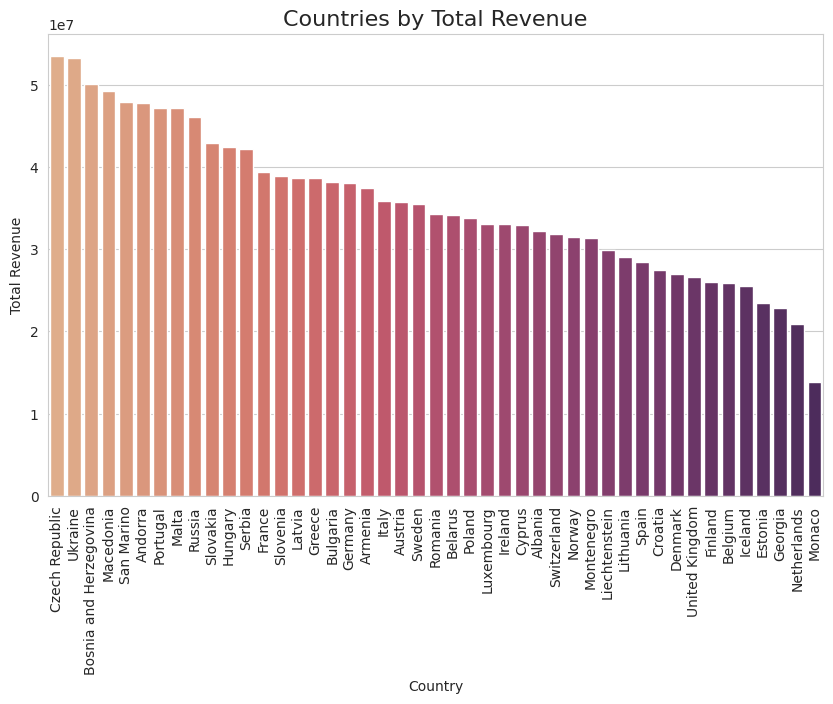

In [ ]:
top_revenue_country = df.groupby('name')['total_revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
colors = sns.color_palette("flare", len(top_revenue_country))

sns.barplot(x=top_revenue_country.index, y=top_revenue_country.values, hue=top_revenue_country.index, palette=colors)
plt.title('Countries by Total Revenue', fontsize=16)
plt.xlabel('Country')
plt.xticks(rotation=90)
plt.ylabel('Total Revenue')
plt.show()

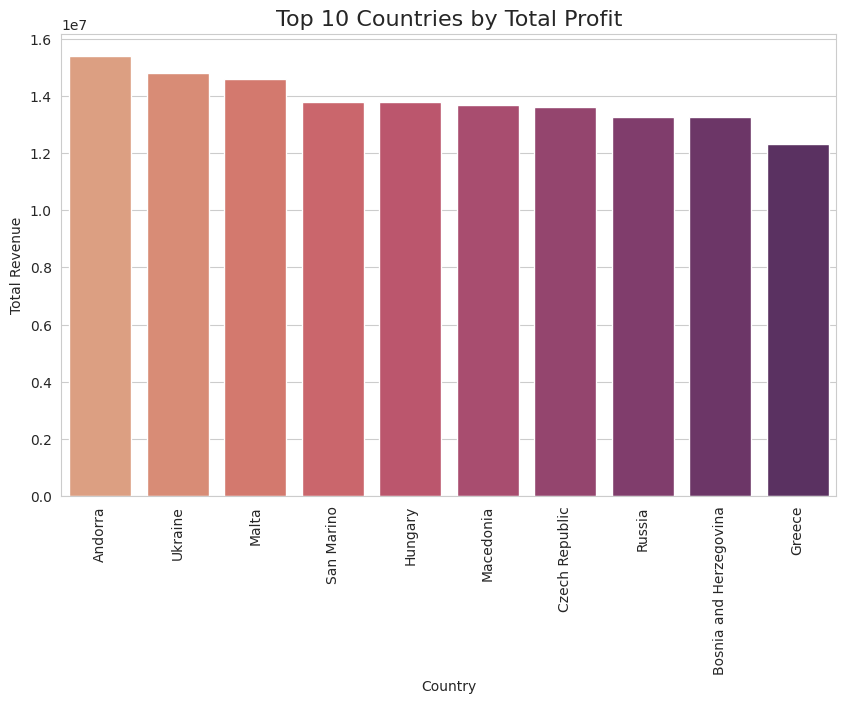

In [ ]:
top_profit_country = df.groupby('name')['profit'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
colors = sns.color_palette("flare", len(top_profit_country.head(10)))

sns.barplot(x=top_profit_country.head(10).index, y=top_profit_country.head(10).values, hue=top_profit_country.head(10).index, palette=colors)
plt.title('Top 10 Countries by Total Profit', fontsize=16)
plt.xlabel('Country')
plt.xticks(rotation=90)
plt.ylabel('Total Revenue')
plt.show()

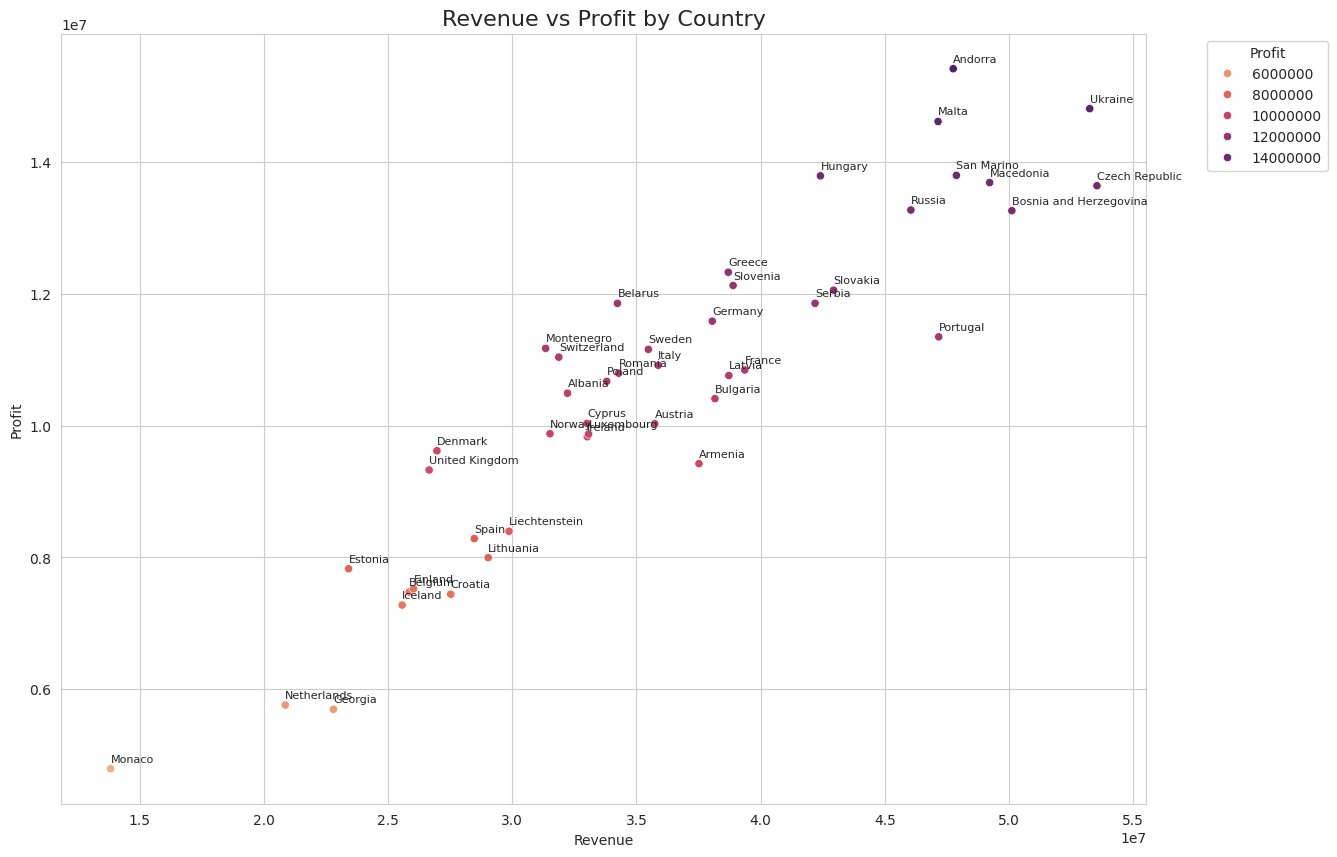

In [ ]:
country_stats = df.groupby('name').agg({
    'total_revenue':'sum',
    'profit':'sum'
}).reset_index()

plt.figure(figsize=(14,10))

sns.scatterplot(data=country_stats, x='total_revenue', y='profit', hue='profit', palette='flare')

for i in range(len(country_stats)):
    plt.text(
        country_stats['total_revenue'][i],
        country_stats['profit'][i] + 100000,
        country_stats['name'][i],
        fontsize=8
    )

plt.title('Revenue vs Profit by Country', fontsize=16)
plt.xlabel('Revenue')
plt.ylabel('Profit')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Profit')
plt.show()

Чим більше revenue — тим більше profit




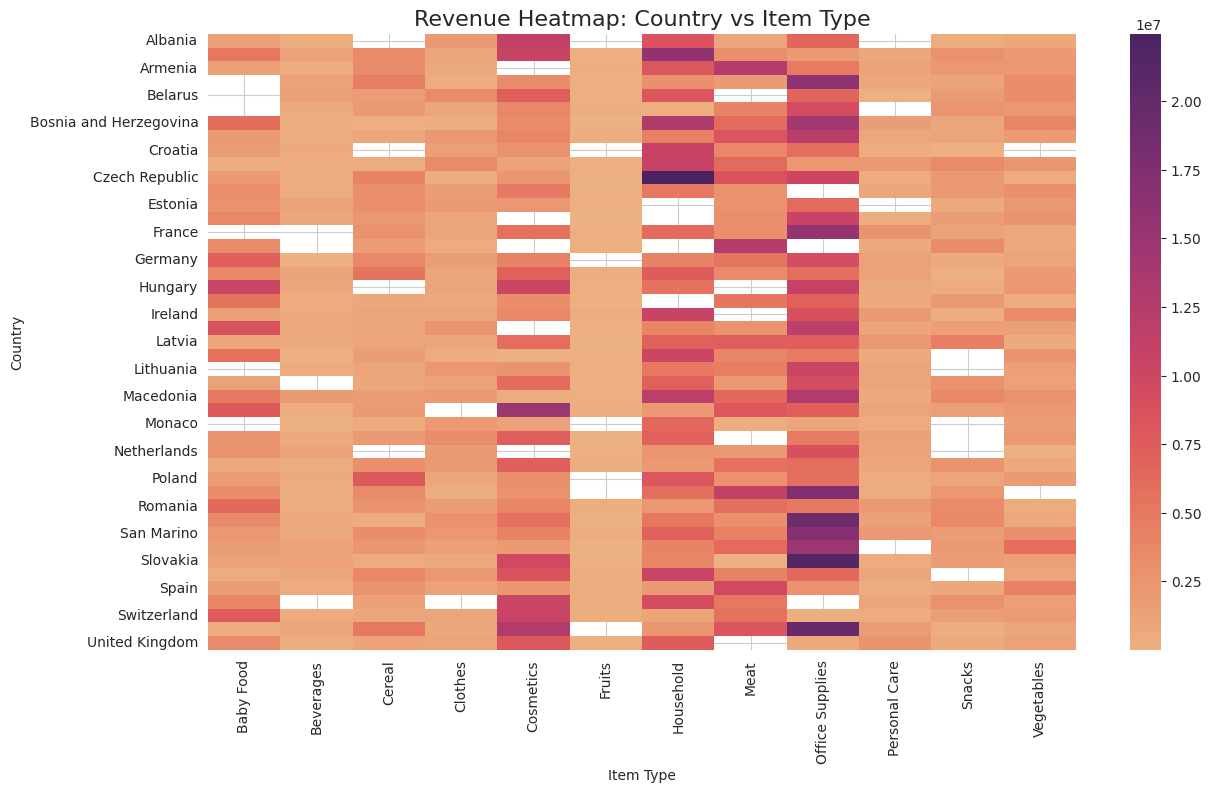

In [ ]:
pivot_country_item = df.pivot_table(
    values='total_revenue',
    index='name',
    columns='item_type',
    aggfunc='sum'
)

plt.figure(figsize=(14,8))
sns.heatmap(pivot_country_item, cmap='flare')

plt.title('Revenue Heatmap: Country vs Item Type', fontsize=16)
plt.xlabel('Item Type')
plt.ylabel('Country')
plt.show()

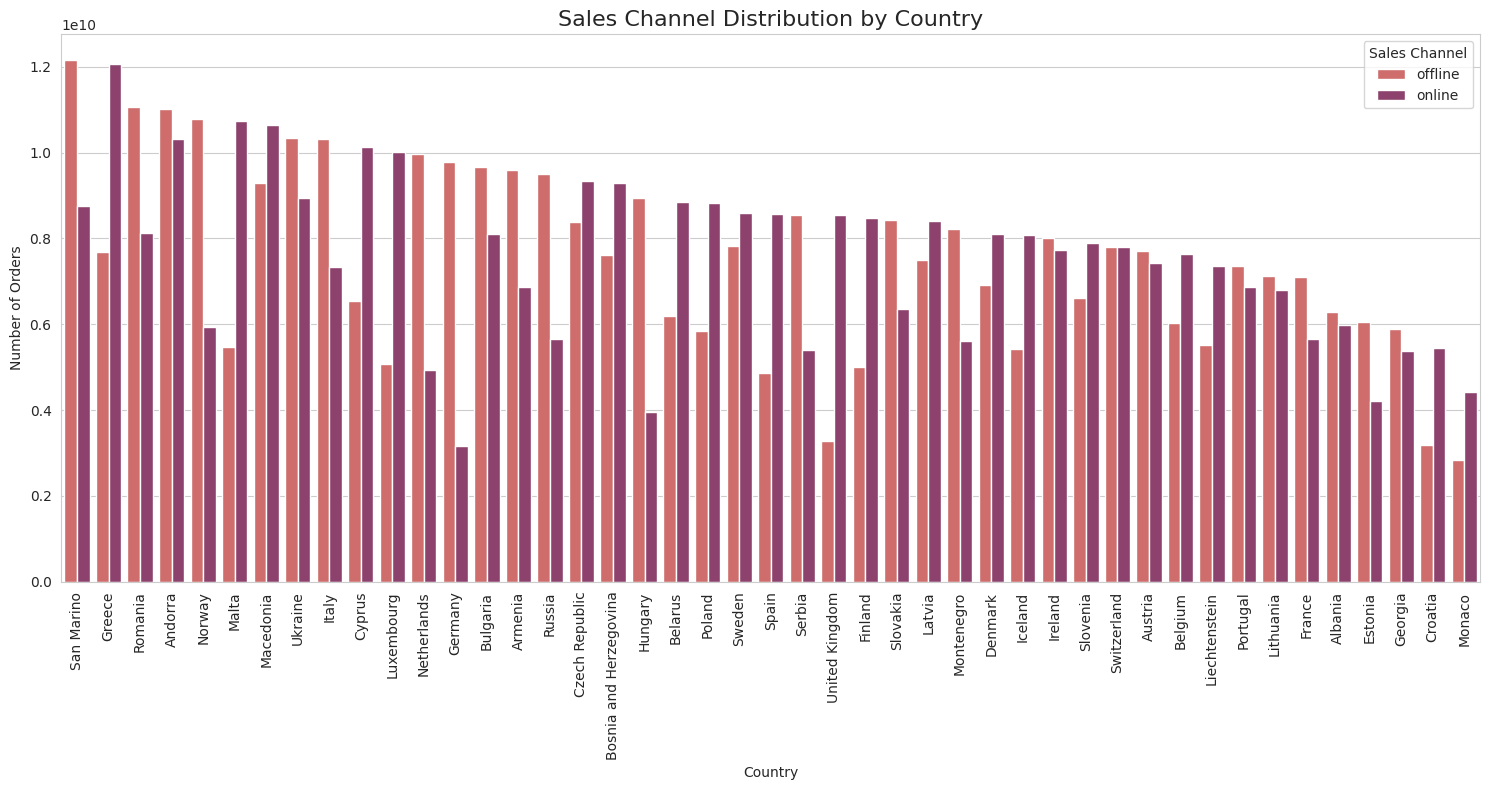

In [ ]:
df['sales_channel'] = df['sales_channel'].str.lower()
country_sales_channel = df.groupby(['name', 'sales_channel'])['order_id'].sum().sort_values(ascending=False).reset_index()


plt.figure(figsize=(15, 8))
sns.barplot(data=country_sales_channel,
            x='name',
            y='order_id',
            hue='sales_channel',
            palette='flare')

plt.title('Sales Channel Distribution by Country', fontsize=16)
plt.xlabel('Country')
plt.xticks(rotation=90)
plt.ylabel('Number of Orders')
plt.legend(title='Sales Channel')
plt.tight_layout()
plt.show()

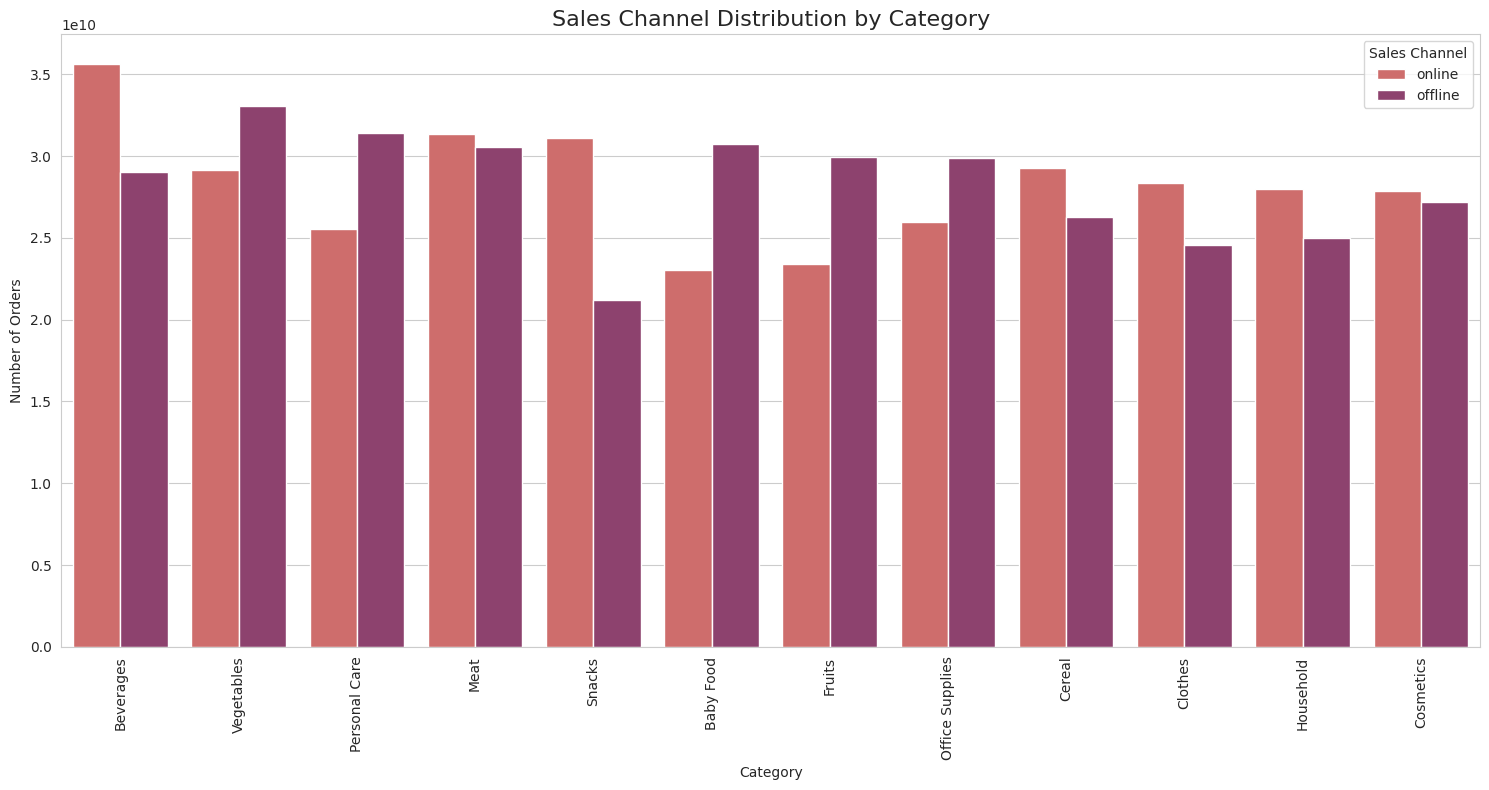

In [ ]:
category_sales_channel = df.groupby(['item_type', 'sales_channel'])['order_id'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(15, 8))
sns.barplot(data=category_sales_channel,
            x='item_type',
            y='order_id',
            hue='sales_channel',
            palette='flare')

plt.title('Sales Channel Distribution by Category', fontsize=16)
plt.xlabel('Category')
plt.xticks(rotation=90)
plt.ylabel('Number of Orders')
plt.legend(title='Sales Channel')
plt.tight_layout()
plt.show()

# **Delivery**

/tmp/ipykernel_1576/3385653315.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=delivery_time_by_country, x='name', y='delivery_time', palette='flare')


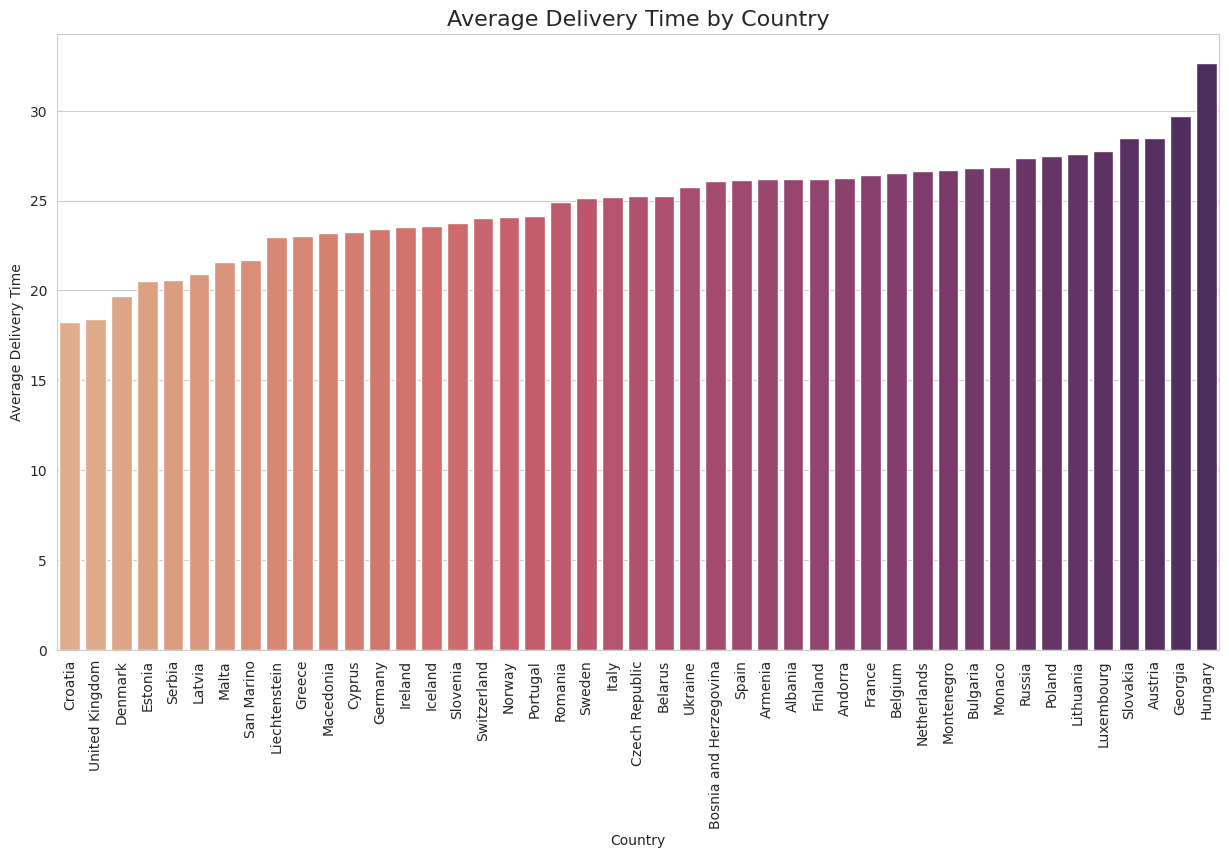

In [ ]:
df['delivery_time'] = (df['ship_date'] - df['order_date']).dt.days
delivery_time_by_country = df.groupby('name')['delivery_time'].mean().sort_values(ascending=True).reset_index()

plt.figure(figsize=(15, 8))
sns.barplot(data=delivery_time_by_country,
            x='name',
            y='delivery_time',
            palette='flare')

plt.title('Average Delivery Time by Country', fontsize=16)
plt.xlabel('Country')
plt.xticks(rotation=90)
plt.ylabel('Average Delivery Time')
plt.show()

/tmp/ipykernel_1576/1427230918.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=delivery_time_by_region, x='region', y='delivery_time', palette='flare')


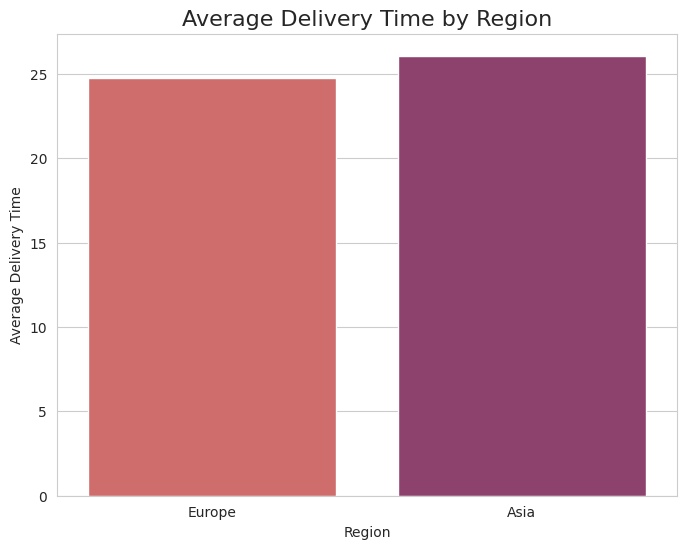

In [ ]:
df['delivery_time'] = (df['ship_date'] - df['order_date']).dt.days
delivery_time_by_region = df.groupby('region')['delivery_time'].mean().sort_values(ascending=True).reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=delivery_time_by_region,
            x='region',
            y='delivery_time',
            palette='flare')

plt.title('Average Delivery Time by Region', fontsize=16)
plt.xlabel('Region')
plt.ylabel('Average Delivery Time')
plt.show()

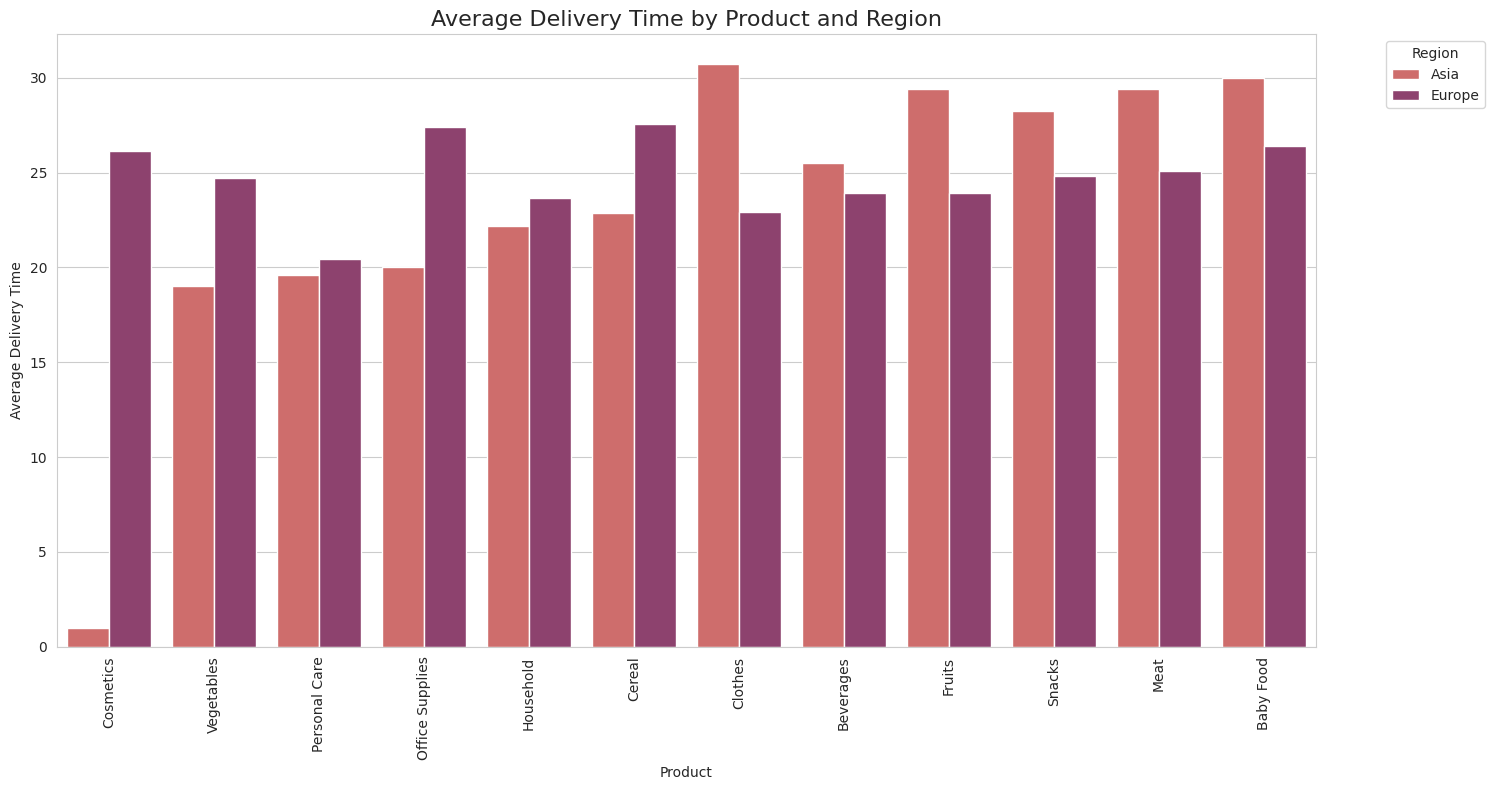

In [ ]:
df['delivery_time'] = (df['ship_date'] - df['order_date']).dt.days
delivery_time_by_product_region = df.groupby(['item_type', 'region'])['delivery_time'].mean().sort_values(ascending=True).reset_index()

plt.figure(figsize=(15, 8))
sns.barplot(data=delivery_time_by_product_region,
            x='item_type',
            y='delivery_time',
            hue='region',
            palette='flare')

plt.title('Average Delivery Time by Product and Region', fontsize=16)
plt.xlabel('Product')
plt.xticks(rotation=90)
plt.ylabel('Average Delivery Time')
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_1576/2596173559.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order_priority_stats, x='order_priority', y='delivery_time', palette='flare')


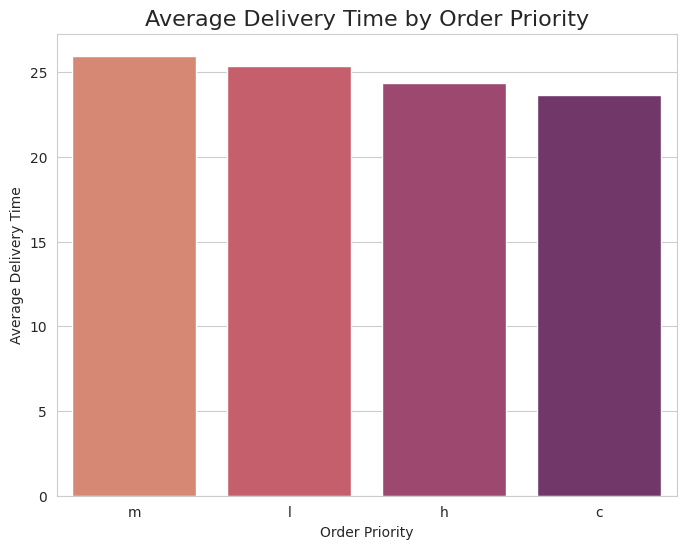

In [ ]:
df['order_priority'] = df['order_priority'].str.strip()

order_priority_stats = df.groupby('order_priority')['delivery_time'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(8, 6))
sns.barplot(data=order_priority_stats,
            x='order_priority',
            y='delivery_time',
            palette='flare')

plt.title('Average Delivery Time by Order Priority', fontsize=16)
plt.xlabel('Order Priority')
plt.ylabel('Average Delivery Time')
plt.show()

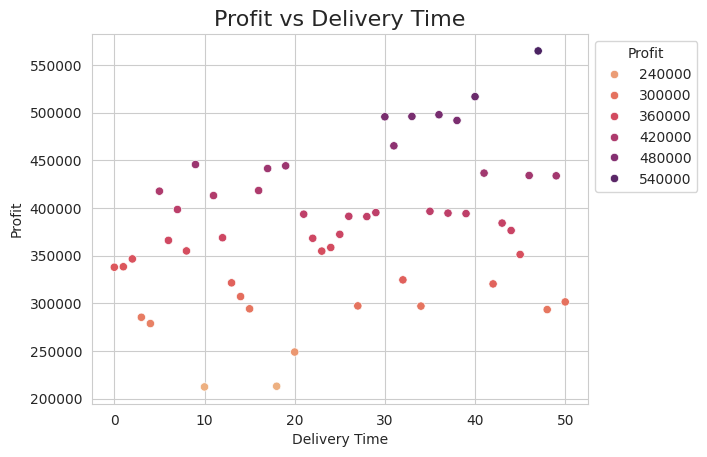

In [ ]:
profit_by_delivery_time = df.groupby('delivery_time')['profit'].mean().reset_index()

sns.scatterplot(data=profit_by_delivery_time,
                x='delivery_time',
                y='profit',
                hue='profit',
                palette='flare')

plt.title('Profit vs Delivery Time', fontsize=16)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', title='Profit')
plt.xlabel('Delivery Time')
plt.ylabel('Profit')
plt.show()


Delivery time не має сильного впливу на profit.

# **Sales dynamics**

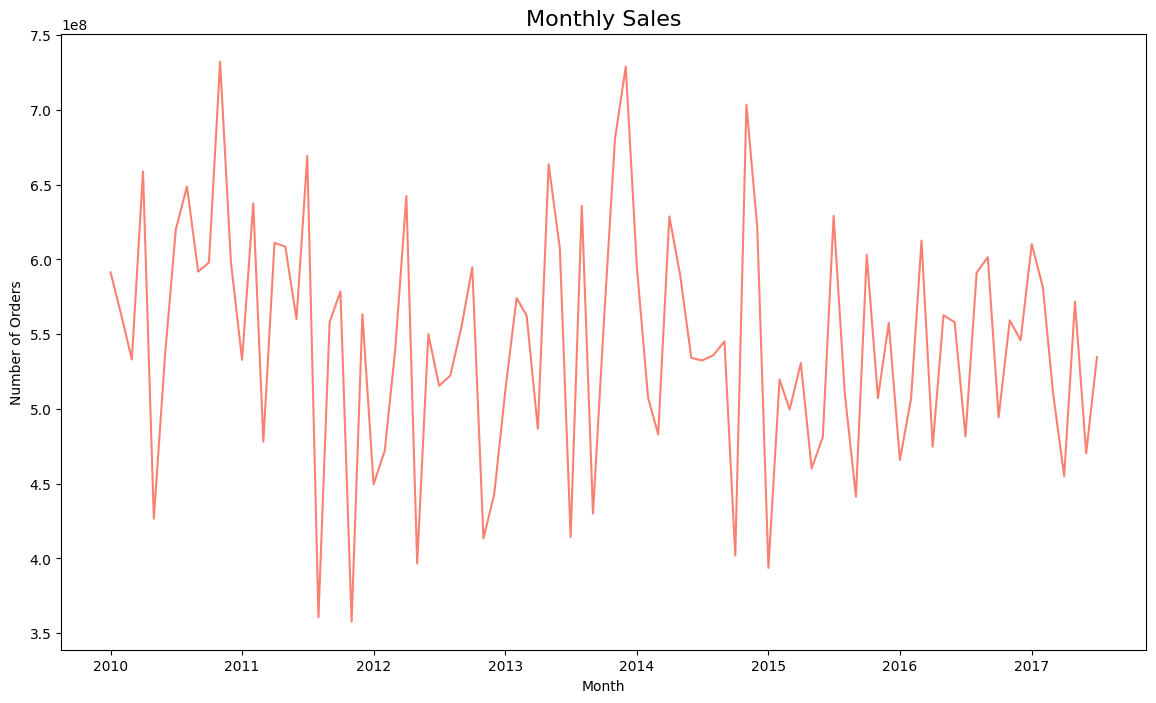

In [ ]:
monthly_sales = df.groupby(df['order_date'].dt.to_period('M'))['order_id'].mean().reset_index()
monthly_sales['order_date'] = monthly_sales['order_date'].dt.to_timestamp()

plt.figure(figsize=(14, 8))
sns.lineplot(data=monthly_sales,
             x='order_date',
             y='order_id',
             color='Salmon')

plt.title('Monthly Sales', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.show()

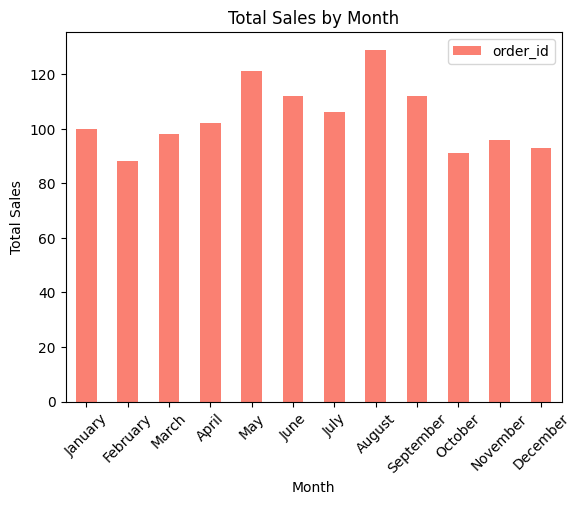

In [ ]:
sales_dynamics_by_month = df.groupby(df['order_date'].dt.month_name())['order_id'].count().reset_index()
sales_dynamics_by_month.index = [
    'January',
    'February',
    'March',
    'April',
    'May',
    'June',
    'July',
    'August',
    'September',
    'October',
    'November',
    'December'
]

sales_dynamics_by_month.plot(kind='bar',
                           xlabel="Month",
                           ylabel="Total Sales",
                           title="Total Sales by Month",
                           color='Salmon'
)
plt.xticks(rotation=45)
plt.show()

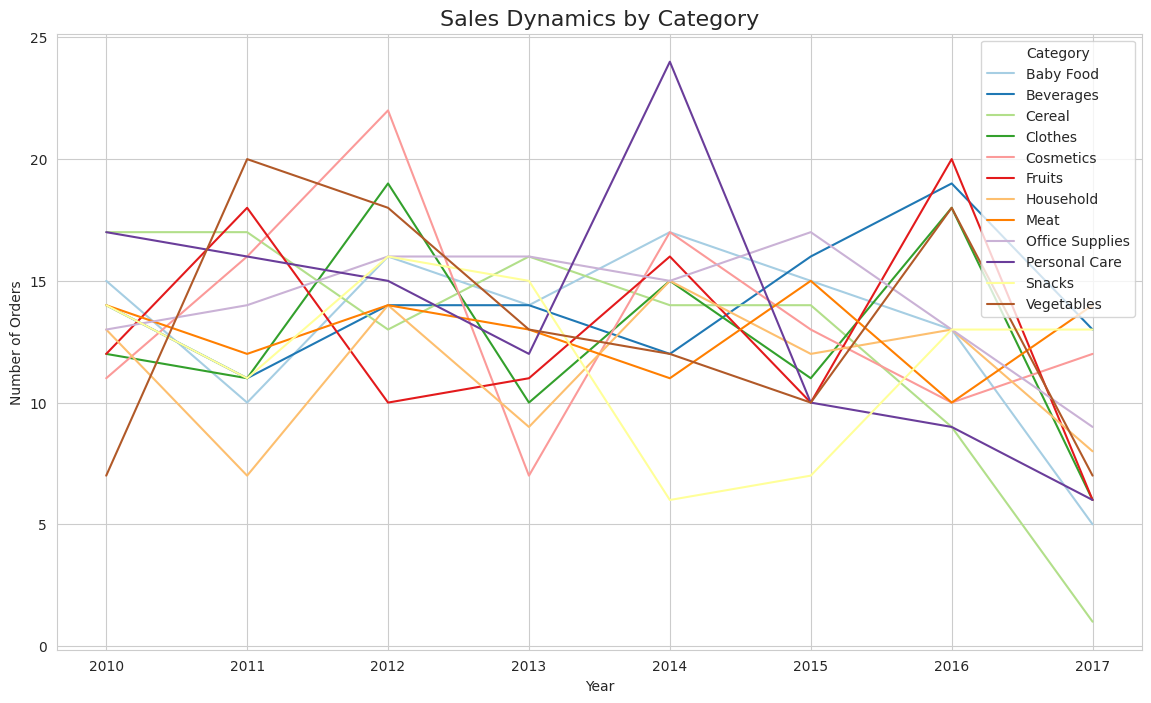

In [ ]:
#Проаналізуй за допомогою візуалізації динаміку продажів (у часі) у розрізі категорій товарів, країн, регіонів, визнач основні тенденції.

sales_dynamics_by_category = df.groupby([df['order_date'].dt.year, 'item_type'])['order_id'].count().reset_index()
sales_dynamics_by_category.rename(columns={'order_date': 'year'}, inplace=True)


plt.figure(figsize=(14, 8))
sns.lineplot(data=sales_dynamics_by_category,
             x='year',
             y='order_id',
             hue='item_type',
             palette='Paired')

plt.title('Sales Dynamics by Category', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Orders')
plt.legend(title='Category')
plt.show()

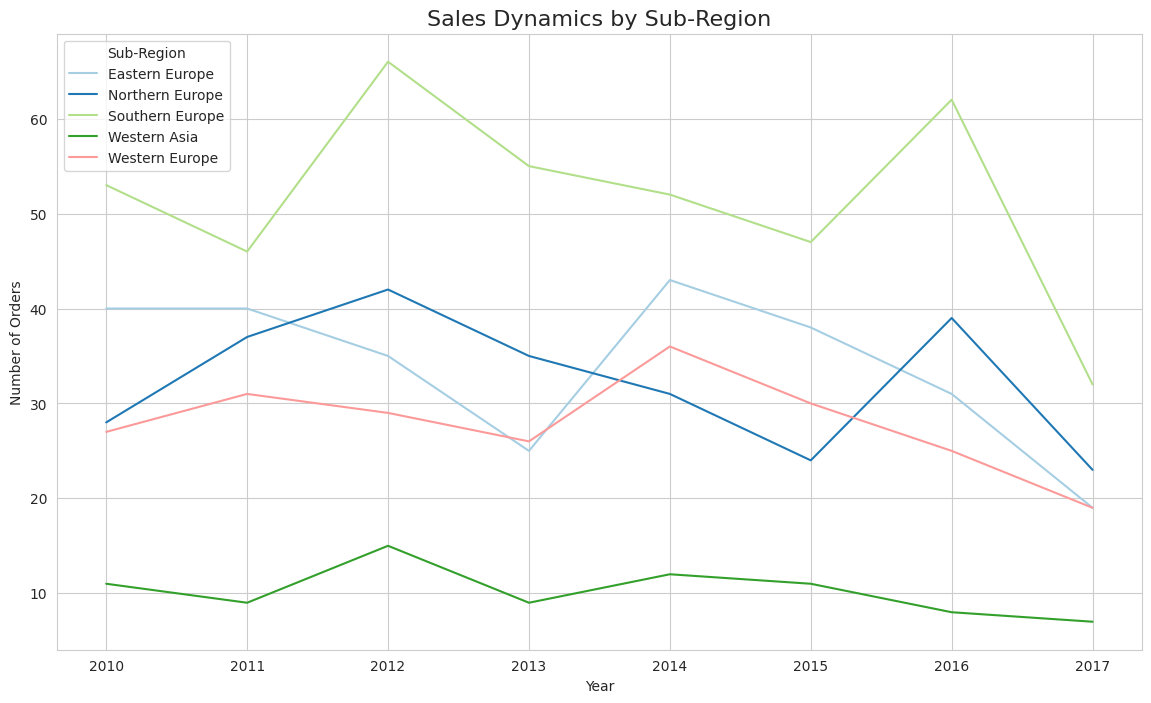

In [ ]:
sales_dynamics_by_sub_region = df.groupby([df['order_date'].dt.year, 'sub_region'])['order_id'].count().reset_index()
sales_dynamics_by_sub_region.rename(columns={'order_date': 'year'}, inplace=True)


plt.figure(figsize=(14, 8))
sns.lineplot(data=sales_dynamics_by_sub_region,
             x='year',
             y='order_id',
             hue='sub_region',
             palette='Paired')

plt.title('Sales Dynamics by Sub-Region', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Orders')
plt.legend(title='Sub-Region')
plt.show()

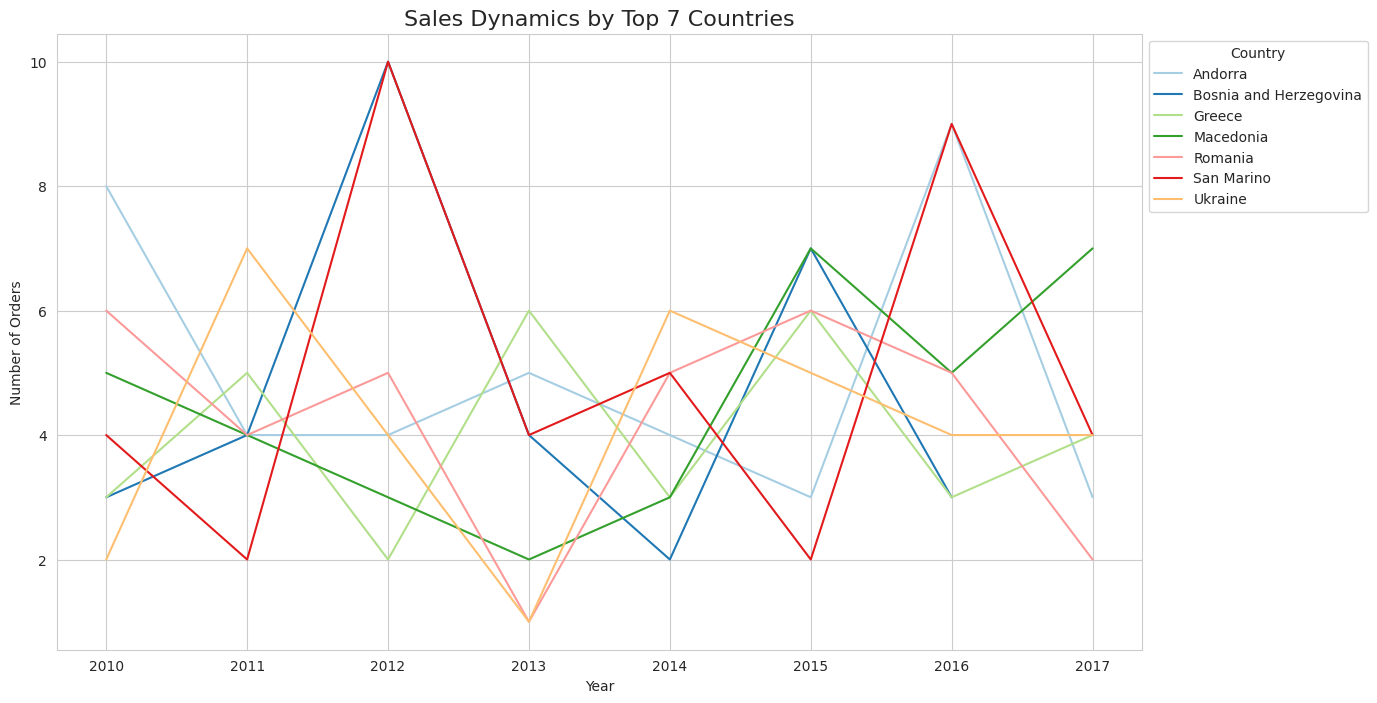

In [ ]:
sales_dynamics_by_country = df.groupby([df['order_date'].dt.year, 'name'])['order_id'].count().reset_index()
sales_dynamics_by_country.rename(columns={'order_date': 'year'}, inplace=True)

top_7_countries_data = sales_dynamics_by_country.groupby('name')['order_id'].sum().nlargest(7).index
sales_dynamics_by_country_top_7 = sales_dynamics_by_country[sales_dynamics_by_country['name'].isin(top_7_countries_data)]


plt.figure(figsize=(14, 8))
sns.lineplot(data=sales_dynamics_by_country_top_7,
             x='year',
             y='order_id',
             hue='name',
             palette='Paired')

plt.title('Sales Dynamics by Top 7 Countries', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Orders')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left', title='Country')
plt.show()

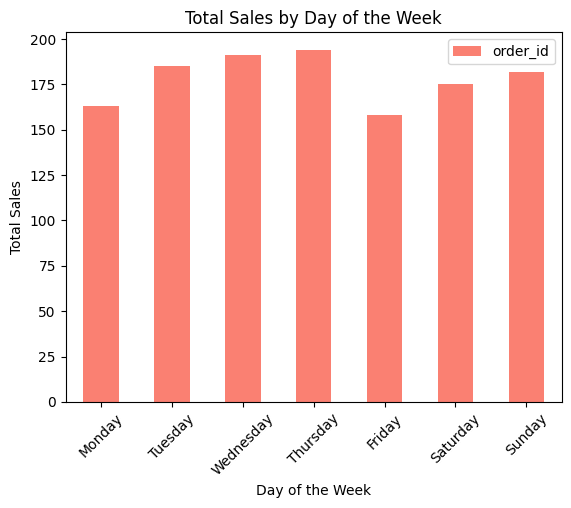

In [ ]:
sales_dynamics_by_day = df.groupby(df['order_date'].dt.day_name())['order_id'].count().reset_index()
sales_dynamics_by_day.index = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

sales_dynamics_by_day.plot(kind='bar',
                           xlabel="Day of the Week",
                           ylabel="Total Sales",
                           title="Total Sales by Day of the Week",
                           color='Salmon'
)
plt.xticks(rotation=45)
plt.show()


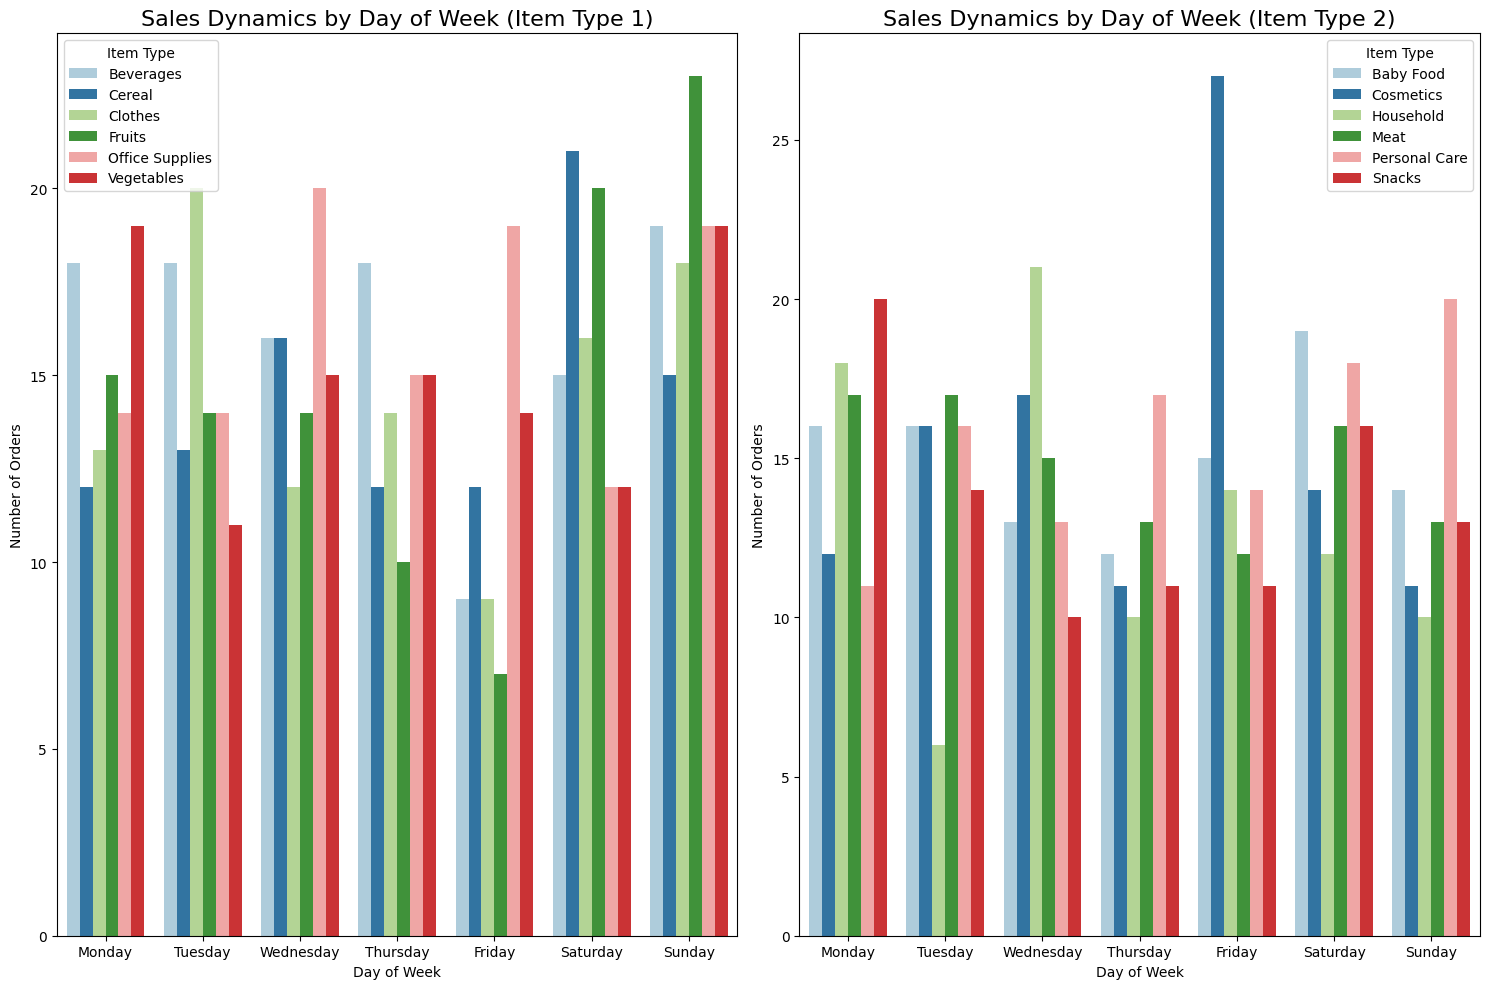

In [ ]:
sales_dynamics_by_day_of_week = df.groupby([df['order_date'].dt.day_name(), 'item_type'])['order_id'].count().reset_index()
sales_dynamics_by_day_of_week.rename(columns={'order_date': 'day_of_week'}, inplace=True)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday",
]

item_tipe_1 = ['Cereal', 'Clothes', 'Beverages', 'Office Supplies', 'Fruits', 'Vegetables']
item_tipe_2 = ['Baby Food', 'Household', 'Meat', 'Cosmetics', 'Snacks', 'Personal Care']

df1 = sales_dynamics_by_day_of_week[sales_dynamics_by_day_of_week['item_type'].isin(item_tipe_1)]
df2 = sales_dynamics_by_day_of_week[sales_dynamics_by_day_of_week['item_type'].isin(item_tipe_2)]

fig, ax = plt.subplots(1, 2, figsize=(15, 10))

sns.barplot(data=df1,
             x='day_of_week',
             y='order_id',
             order=day_order,
             hue='item_type',
             ax=ax[0],
             palette='Paired')
ax[0].set_title('Sales Dynamics by Day of Week (Item Type 1)', fontsize=16)
ax[0].set_xlabel('Day of Week')
ax[0].set_ylabel('Number of Orders')
ax[0].legend(title='Item Type')

sns.barplot(data=df2,
             x='day_of_week',
             y='order_id',
             order=day_order,
             hue='item_type',
             ax=ax[1],
             palette='Paired')
ax[1].set_title('Sales Dynamics by Day of Week (Item Type 2)', fontsize=16)
ax[1].set_xlabel('Day of Week')
ax[1].set_ylabel('Number of Orders')
ax[1].legend(title='Item Type')

plt.tight_layout()
plt.show()

# **Reporting**

### **Опис даних**

Для аналізу було використано три основні набори даних:
* events — інформація про замовлення
* products — інформація про товари
* countries — інформація про країни   
Також були розраховані додаткові метрики:   
Revenue = Units Sold × Unit Price   
Cost = Units Sold × Unit Cost   
Profit = Revenue − Cost


###**Загальні метрики**

Період даних: 2010 – 2017  
Замовлень: 1248  
Проданих одиниць: 6 181 595    
Країн: 45   
Середня доставка: ≈25 днів

Revenue: 1.60B      
Cost: 1.13B  
Profit: 474M

Прибуток становить приблизно 29.6% від загального доходу, свідчить про високий рівень рентабельності.

### **Sales analysis**
**Categories**    
Було проаналізовано:
* кількість проданих одиниць
* загальний дохід
* загальні витрати
* прибуток    

Деякі категорії товарів мають дуже високий обсяг продажів, що робить їх важливими для підтримання загального обороту компанії: Office Supplies, Clothes, Beverages.   

Водночас інші категорії можуть мати менший обсяг продажів, але генерувати значно більший прибуток через вищу маржинальність: Cosmetics, Office Supplies, Household.

**Countries**   
Czech Republic, Ukraine, Bosnia and Herzegovina, Macedonia, San Marino формують значну частку загального доходу компанії та є ключовими ринками для бізнесу.    

Andorra, Ukraine, Malta, San Marino, Hungary мають найвищі показники прибутковості



### **Sales channels**
У датасеті представлені два основні канали продажу:
* Online
* Offline
Аналіз показав, що розподіл продажів суттєво відрізняється від країни та категорії товару.

### **Delivery**

Середній час доставки становить приблизно 24 дні.
Було проведено аналіз часу доставки:
* за країнами
* за регіонами
* за категоріями товарів
* за пріоритетом замовлення    

Результати показали, що час доставки суттєво відрізняється залежно від географічного регіону. Також графіки показали, що час доставки не має значного впливу на прибуток

### **Time dynamics**
Аналіз часової динаміки продажів показав зміни кількості замовлень у різні періоди.
Було досліджено:
* щомісячну динаміку продажів
* сезонність продажів
* динаміку продажів за категоріями товарів
Аналіз  показав, що деякі категорії товарів демонструють стабільне зростання продажів у часі та мають свою сезонність.

### **Conclusion**
**Масштабувати** високомаржинальні категорії - Cereal, Fruits, Vegetables.  
**Оптимізувати** низькомаржинальні продукти - Cosmetics, Office Supplies, Household.   
**Розширювати** присутність компанії на найбільш прибуткових міжнародних ринках Andorra, Ukraine, Malta, San Marino, Hungary
**Покращувати** логістичні процеси для забезпечення своєчасної доставки товарів.